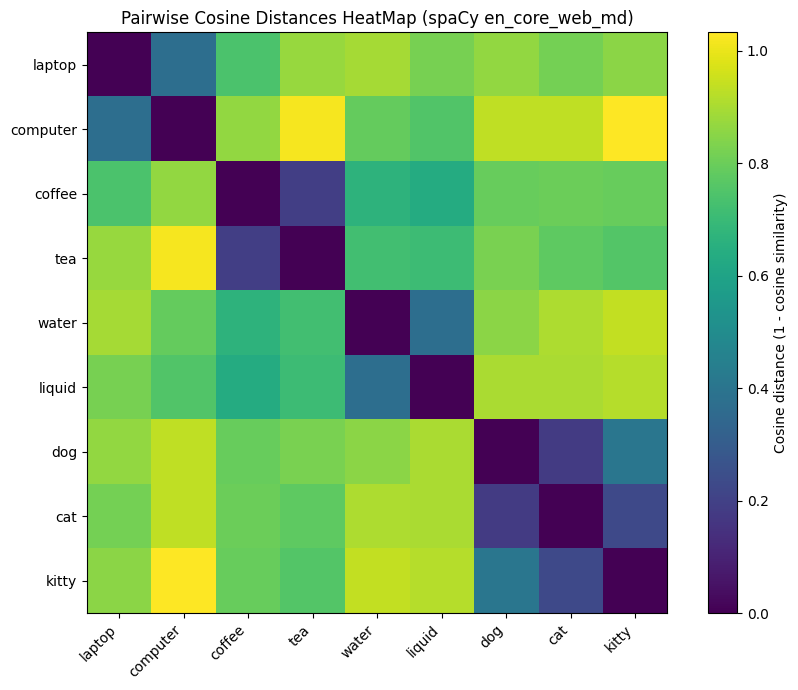

In [1]:
import spacy
import numpy as np
import matplotlib.pyplot as plt

# Load medium model (has real word vectors)
nlp = spacy.load("en_core_web_md")

text = "laptop computer coffee tea water liquid dog cat kitty"
words = text.split()

# Get vectors for each word
vectors = np.array([nlp(w).vector for w in words])

# Cosine similarity matrix
# sim[i,j] = (vi · vj) / (||vi|| * ||vj||)
norms = np.linalg.norm(vectors, axis=1, keepdims=True)
unit = vectors / (norms + 1e-12)
cos_sim = unit @ unit.T

# Cosine distance = 1 - cosine similarity
cos_dist = 1 - cos_sim

# Plot heatmap
plt.figure(figsize=(9, 7))
plt.imshow(cos_dist, interpolation="nearest")
plt.colorbar(label="Cosine distance (1 - cosine similarity)")

plt.xticks(range(len(words)), words, rotation=45, ha="right")
plt.yticks(range(len(words)), words)

plt.title("Pairwise Cosine Distances HeatMap (spaCy en_core_web_md)")
plt.tight_layout()
plt.show()
